# Implementation of the equations that make up the GSW functions for calculating the seawater surface density. A summary of the necessary steps are given in the cell below. 

# Mathematical equations

The **main equation** used is: 

$$
\hat{v} (S_A \Theta, p ) = v_u \sum_{i,j,k} v_{ijk} s^i \tau^j \pi^k  \tag{1}
$$

Where the values associated with i,j,k are given in the TEOS10 manual in Appendix K. 

$$
s = \sqrt{\frac{S_A + 24 gkg^-1}{S_{A_u}}}, \quad S_{A_u} = \frac{40 \times 35.16504 g kg^{-1}}{35}
$$

$$
\tau = \frac{\Theta}{\Theta_u}, \quad \Theta_u = 40^{\circ} C  
$$

$$
\pi = \frac{p}{p_u}, \quad P_u = 10^4 dbar
$$

$$
v_u = 1m^{3} kg^{-1}, \quad 
$$

However, p = 0 in this function and therefore $\pi \rightarrow 0$ when $k > 0$. Thats why the GSW function only needs salinity and temperature, not pressure for calculating the surface density: 

$$\hat{v} (S_A, \Theta, p = 0)$$


**Furthermore**, we also need to calculate the conserved temperature to use in the main equation. The following related equations are dedicated to this process.

For calculating the conserved temperature, we need to calculate both the entropy and a potential entalpi! The following steps are therefore needed in the calculations:

1. Calculation of the entropy (equation 2.10.1 from the TEOS manual): 

$$
\eta = \eta(S_A, t, p) = -g_T = - \frac{\partial g_T}{\partial T} \tag{2}
$$

In TEOS - empirical values are already used to create polynomial functions of $\eta$ - and I will rather use these estimated values directly with the aimn to reduce the need for computational calculations. These approximated values are found in appendix B of the TEOS and Copernicus manual! https://os.copernicus.org/articles/19/1719/2023/os-19-1719-2023.pdf

2. An iterativ calculation of potential temperature for the surface - ie. $\theta_0$. This is calculated using the Newton-Raphson iterative technique as illustrated in the equation below, found from TEOS10. It can also be estimated as an integral of the adiabatic lapse rate (Fofonoff, 1962 \& 1985), but I also suspect this would require potentially unneseccary computational power. 

$$
\eta (S_A, \theta, p_r) = \eta (S_A, t, p) \tag{3}
$$

The Newton Raphson iterative process is:
$$
x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)} \tag{4}
$$

Where we have to differentiate $g_t$ in our calculations. Furthermore, the full thermodynamic equation of entropy is given as: 

$$
\hat{\eta} (S_A, \Theta) = c_p^0 ln(1 + \Theta / T_0) + \alpha (\frac{S_A}{S_{SO}}) ln (\frac{S_A}{S_{SO}}) + P \{ 8,8 \} (s, \tau) \tag{5}
$$

Where: 

$$
T_0 = 273.15, \quad c_p^0 = 3991.86795711963 , \quad \alpha = - 9.309495003228781 , \quad S_{SO} = 35.16504 
$$

and the polynomial is differentiated such that the potency of $\tau$ \& $s$ is subtracted according to standard differentiation rules. 

3. Then we have to calculate the potential entalpy, where the reference pressure is always set to be zero because most heat flux activity is near the sea-surface. The reference pressure $p_r = 0$ dbar. This is calculated by using: 

$$
h^0 (S_A, t, p) = h (S_A, \theta, 0) = g(S_A, \theta, 0) - (T_0 + \theta)g_T (S_A, \theta, 0) \tag{6}
$$ 

Shortened to (I think - this is my doing hehe):
$$
h^0 = G - T * g_t 
$$

4. And yuhu now we can finally calculate the conserved temperature! Again with the use of the TEOS equations: 

$$
\Theta (S_A, t, p) = \tilde{\Theta} (S_A, \theta) = \frac{\tilde{h^0}(S_A, \theta)}{c_p^0} \tag{7}

$$

We have to differentiate the logarthitmic expression also. The second term $\rightarrow 0$, because it is independent of $\Theta$. So we are left with:

$$

\frac{\partial}{\partial \Theta} (c_p \cdot ln(1+ \frac{\Theta}{T_0})) =
(\frac{c_p}{T_0 + \Theta})'
$$


Potential entalpy

reference pressure = 0dbar = 1013hPa

Remember that $g_T$ is the Gibbs temperature derivated function, while $g = $ the non-derivated function.

$\eta = -g_T$

# Test blocks

In [73]:
from gsw_teos10_implementation import * 

In [74]:
#Test values
salinity = 33.5
Temp = 15

In [75]:
e_target, _ = entropy(SA = salinity, Theta = Temp)

In [76]:
density_field(SA = salinity, entropy_tar=e_target)

theta = 15.00000000000002, h0 = 59878.019356794524, Theta = 15.00000000000002
15.00000000000002
s = 1.2017813563920139, tau = 0.3750000000000005


(np.float64(1025.1193009880922), np.float64(25.119300988092164))

In [77]:
SA_test = 35.0
Theta_test = 15.0

eta_target, _ = entropy(SA_test, Theta_test)
print(f"Gitt: SA = {SA_test} g/kg, Theta_sann = {Theta_test} degC")
print(f"  -> entropi = {eta_target:.6f} J/(kg K)\n")

# Steg 1: entropi -> Theta (Newton-Raphson)
Theta_hat = theta_from_entropy(SA_test, eta_target)
print(f"[Steg 1] Theta fra Newton-Raphson       = {Theta_hat:.10f} degC "
      f"(avvik fra sann verdi: {Theta_hat - Theta_test:.2e} degC)")

# Steg 2: potensiell entalpi
h0 = potential_enthalpy(Theta_hat)
print(f"[Steg 2] potensiell entalpi h0           = {h0:.6f} J/kg")

# Steg 3: konservativ temperatur
CT_hat = conservative_T(h0)
print(f"[Steg 3] CT = h0/cp0                     = {CT_hat:.10f} degC\n")

print(f"Samlefunksjon CT_from_entropy()          = {CT(SA_test, eta_target):.10f} degC")

Gitt: SA = 35.0 g/kg, Theta_sann = 15.0 degC
  -> entropi = 213.440395 J/(kg K)

[Steg 1] Theta fra Newton-Raphson       = 15.0000000000 degC (avvik fra sann verdi: -2.31e-14 degC)
[Steg 2] potensiell entalpi h0           = 59878.019357 J/kg
[Steg 3] CT = h0/cp0                     = 15.0000000000 degC

theta = 14.999999999999977, h0 = 59878.01935679436, Theta = 14.999999999999977
Samlefunksjon CT_from_entropy()          = 15.0000000000 degC


In [78]:
v_hat = coeff_75term_polynomial(SA_test, eta_target)
print(f'v hat{v_hat}')
d = density_field(SA = salinity, entropy_tar=e_target)
print(f'Density field : {d}')

theta = 14.999999999999977, h0 = 59878.01935679436, Theta = 14.999999999999977
14.999999999999977
s = 1.2173558465554997, tau = 0.37499999999999944
v hat0.0009744001750633938
theta = 15.00000000000002, h0 = 59878.019356794524, Theta = 15.00000000000002
15.00000000000002
s = 1.2017813563920139, tau = 0.3750000000000005
Density field : (np.float64(1025.1193009880922), np.float64(25.119300988092164))


In [79]:
print(1 / v_hat) 

1026.2723936137847


In [80]:
import gsw

In [81]:
gsw.sigma0(SA_test, Theta_test)

np.float64(25.847622175753486)

# Norkyst test

In [82]:
filepath = '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024' 
norkyst_path = 'norkyst800-20240501.nc'
import xarray as xr 
ds = xr.open_dataset(f'{filepath}/{norkyst_path}').isel(s_rho = -1)

In [83]:
salinity_norkyst = ds.salinity.values.ravel()
temperature_norkyst = ds.temperature.values.ravel()

In [84]:
"""
Testing the functions - we need the following: 

1. Create the entropy target
eta_target, _ = entropy(SA = salinity, theta = temperature) 

2. Use entropy target and salinity to calculate the rest 
density_field(SA = salinity, entropy_tar = eta_target)

"""

#eta_target_norkyst, _ = entropy(SA = salinity_norkyst, Theta= temperature_norkyst)
#Time: 3 min and 49 seconds for one day

'\nTesting the functions - we need the following: \n\n1. Create the entropy target\neta_target, _ = entropy(SA = salinity, theta = temperature) \n\n2. Use entropy target and salinity to calculate the rest \ndensity_field(SA = salinity, entropy_tar = eta_target)\n\n'

In [85]:
#density_field_norkyst = density_field(SA = salinity, entropy_tar=eta_target_norkyst)

In [86]:
filepath_mean = '/lustre/storeB/project/fou/hi/foccus/datasets/norkystv3_averages'
checkpoint_mai_mean = 'norkyst800-202405_avg.nc'

ds_avg = xr.open_dataset(f'{filepath_mean}/{checkpoint_mai_mean}')

In [87]:
ds_avg

<xarray.Dataset> Size: 214MB
Dimensions:           (Y: 1148, X: 2747)
Coordinates:
    s_rho             float64 8B ...
  * X                 (X) float64 22kB 0.0 800.0 1.6e+03 ... 2.196e+06 2.197e+06
  * Y                 (Y) float64 9kB 0.0 800.0 1.6e+03 ... 9.168e+05 9.176e+05
    s_w               float64 8B ...
    lon               (Y, X) float64 25MB ...
    lat               (Y, X) float64 25MB ...
Data variables: (12/18)
    Uwind_eastward    (Y, X) float32 13MB ...
    Vwind_northward   (Y, X) float32 13MB ...
    zeta              (Y, X) float32 13MB ...
    ubar_eastward     (Y, X) float32 13MB ...
    vbar_northward    (Y, X) float32 13MB ...
    u_eastward        (Y, X) float32 13MB ...
    ...                ...
    hc                float64 8B ...
    Cs_r              float64 8B ...
    Cs_w              float64 8B ...
    h                 (Y, X) float32 13MB ...
    projection_stere  float64 8B ...
    depth             float64 8B ...
Attributes: (12/33)
    id:                      269f9aec-22a2-423e-8f43-6dd38a36bf34
    naming_authority:        no.met
    operational_status:      scientific
    iso_topic_category:      oceans
    activity_type:           Numerical Simulation
    keywords_vocabulary:     GCMDSK:GCMD Science Keywords:https://gcmd.earthd...
    ...                      ...
    project:                 Norkyst_v3
    license:                 https://spdx.org/licenses/CC-BY-4.0 (CC-BY-4.0)
    title:                   Norkyst-800m - ROMS, Norkyst-800m ocean hindcast...
    summary:                 Norkyst-800m (Norwegian Coast 800m horizontal re...
    title_no:                Hindcast prognoser fra havmodellen Norkyst-800m,...
    summary_no:              NorKyst-800m (Norske kystområder med 800m horiso...

In [88]:
salinity_avg = ds_avg.salinity.values
temperature_avg = ds_avg.temperature.values

In [89]:
eta_target_avg, _ = entropy(SA = salinity_avg, Theta= temperature_avg)
density_field_avg, density_field_avg_amomaly = density_field(SA = salinity_avg, entropy_tar= eta_target_avg)

theta = [[       nan        nan        nan ... 2.2333958  2.2367175  2.2349584 ]
 [       nan        nan        nan ... 2.2195892  2.2200456  2.2331355 ]
 [       nan        nan        nan ... 2.220273   2.2215762  2.2366846 ]
 ...
 [       nan        nan        nan ... 0.37498403 0.3955958  0.4497464 ]
 [       nan        nan        nan ... 0.4475973  0.465539   0.50448316]
 [       nan        nan        nan ... 0.5255507  0.5442088  0.52437854]], h0 = [[      nan       nan       nan ... 8915.421  8928.681  8921.659 ]
 [      nan       nan       nan ... 8860.307  8862.129  8914.382 ]
 [      nan       nan       nan ... 8863.037  8868.239  8928.55  ]
 ...
 [      nan       nan       nan ... 1496.8867 1579.1661 1795.3282]
 [      nan       nan       nan ... 1786.7493 1858.3702 2013.8302]
 [      nan       nan       nan ... 2097.929  2172.4097 2093.2498]], Theta = [[       nan        nan        nan ... 2.2333958  2.2367175  2.2349584 ]
 [       nan        nan        nan ... 2.2195892  2.

In [90]:
density_field_avg

array([[      nan,       nan,       nan, ..., 1027.6781, 1027.6749,
        1027.6781],
       [      nan,       nan,       nan, ..., 1027.6859, 1027.6837,
        1027.6808],
       [      nan,       nan,       nan, ..., 1027.6893, 1027.6855,
        1027.6769],
       ...,
       [      nan,       nan,       nan, ..., 1027.8884, 1027.881 ,
        1027.87  ],
       [      nan,       nan,       nan, ..., 1027.8763, 1027.8705,
        1027.8617],
       [      nan,       nan,       nan, ..., 1027.8635, 1027.8594,
        1027.8606]], shape=(1148, 2747), dtype=float32)

In [91]:
#calculate with gsw
density_avg_gsw = gsw.sigma0(salinity_avg, temperature_avg)
density_avg_gsw += 1000

In [92]:
density_avg_gsw

array([[          nan,           nan,           nan, ..., 1027.23979467,
        1027.23650491, 1027.23949901],
       [          nan,           nan,           nan, ..., 1027.24732939,
        1027.24513375, 1027.24246451],
       [          nan,           nan,           nan, ..., 1027.25080714,
        1027.24688306, 1027.23842594],
       ...,
       [          nan,           nan,           nan, ..., 1027.4461216 ,
        1027.43886409, 1027.42808832],
       [          nan,           nan,           nan, ..., 1027.43420006,
        1027.42863298, 1027.4196225 ],
       [          nan,           nan,           nan, ..., 1027.42172698,
        1027.41731321, 1027.41845139]], shape=(1148, 2747))

In [93]:
import matplotlib.pyplot as plt

In [94]:
import cartopy
import cmocean #using haline cmocean color 
import cartopy.crs as ccrs #cartopy north stereo

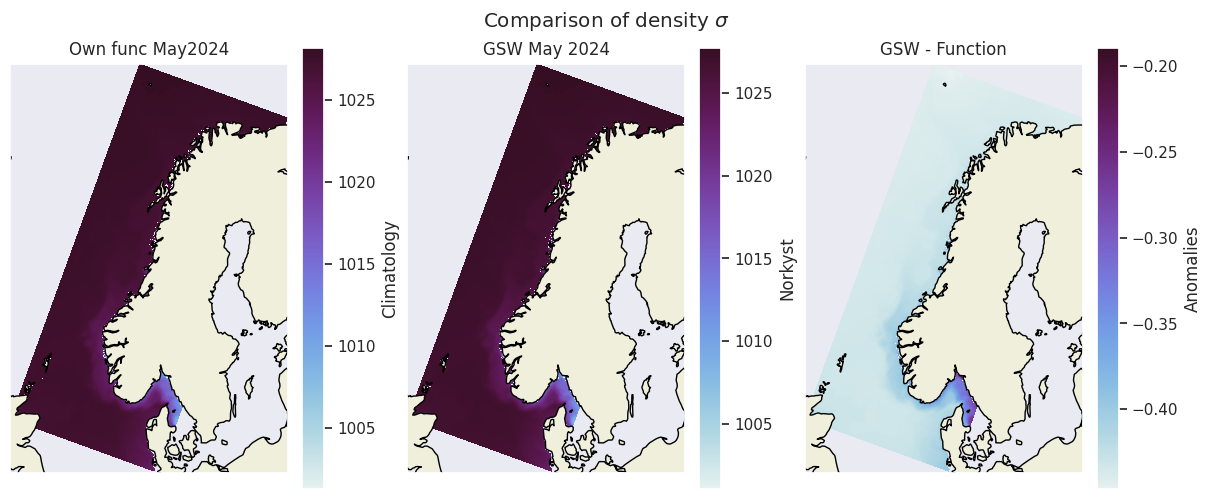

In [95]:
fig, axes = plt.subplots(1,3, figsize = (12, 10), layout = 'compressed', subplot_kw= { 'projection' : ccrs.NorthPolarStereo()})

#Own function
ax_clim = axes[0]
im1 = ax_clim.pcolormesh(ds_avg.lon, ds_avg.lat, density_field_avg, cmap = cmocean.cm.dense, transform = ccrs.PlateCarree())
ax_clim.set_title(f'Own func May2024') 
ax_clim.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar1 = fig.colorbar(im1, ax=ax_clim, orientation = 'vertical')
cbar1.set_label('Climatology', fontsize = 12)

#GSW function
ax_norkyst = axes[1]
im2 = ax_norkyst.pcolormesh(ds_avg.lon, ds_avg.lat, density_avg_gsw, cmap = cmocean.cm.dense, transform = ccrs.PlateCarree())
ax_norkyst.set_title(f'GSW May 2024') 
ax_norkyst.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar2 = fig.colorbar(im2, ax=ax_norkyst, orientation = 'vertical')
cbar2.set_label('Norkyst', fontsize = 12)

#diff
ax_anomaly = axes[2]
im3 = axes[2].pcolormesh(ds_avg.lon, ds_avg.lat, density_avg_gsw - density_field_avg, cmap = cmocean.cm.dense, transform = ccrs.PlateCarree())
ax_anomaly.set_title(f'GSW - Function') 
ax_anomaly.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar2 = fig.colorbar(im3, ax=ax_anomaly, orientation = 'vertical')
cbar2.set_label('Anomalies', fontsize = 12)
for ax in [ax_clim, ax_norkyst, ax_anomaly]:
    ax.set_ylabel('Latitude')
    ax.set_xlabel('Longitude')
    
plt.suptitle(r'Comparison of density $\sigma$')
plt.show()



In [96]:
#test to find the maximum and average difference between the GSW and the own function
diff = density_avg_gsw - density_field_avg

In [97]:
#preview
print(diff.shape)
print(density_avg_gsw.shape)
print(density_field_avg.shape)

(1148, 2747)
(1148, 2747)
(1148, 2747)


In [98]:
own_dropped = density_field_avg[~np.isnan(density_field_avg)]
gsw_dropped = density_avg_gsw[~np.isnan(density_avg_gsw)]
print(own_dropped.shape)
print(gsw_dropped.shape)

(1822664,)
(1822664,)


In [99]:
diff_no_nans = gsw_dropped - own_dropped
diff_no_nans

array([-0.33147621, -0.32776397, -0.32195049, ..., -0.44179841,
       -0.44206179, -0.44214432], shape=(1822664,))

In [100]:
import seaborn as sns

/tmp/ipykernel_1775304/1173800883.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


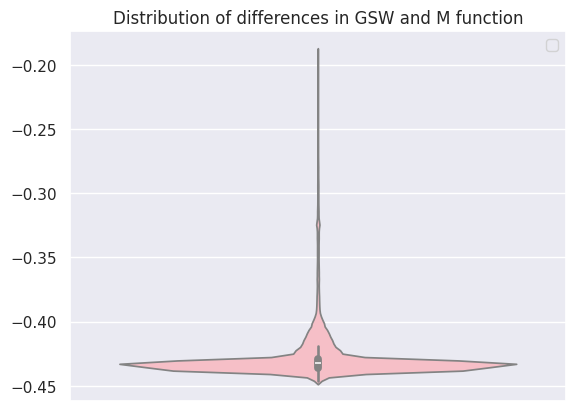

In [101]:
sns.set_theme(style = 'darkgrid' )
sns.violinplot(diff_no_nans, color = 'lightpink')
plt.title(f'Distribution of differences in GSW and M function')
plt.legend()

Text(0.5, 1.0, 'The histogram distribution of density')

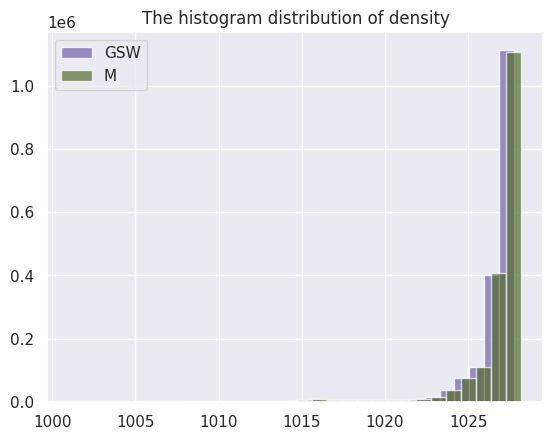

In [102]:
plt.hist(density_avg_gsw.flatten(), label = 'GSW', color = 'm', alpha = 0.8, bins = 30)
plt.hist(density_field_avg.flatten(), color = 'darkolivegreen', label = 'M', alpha = 0.7, bins = 30)
plt.legend()
plt.title(f'The histogram distribution of density')

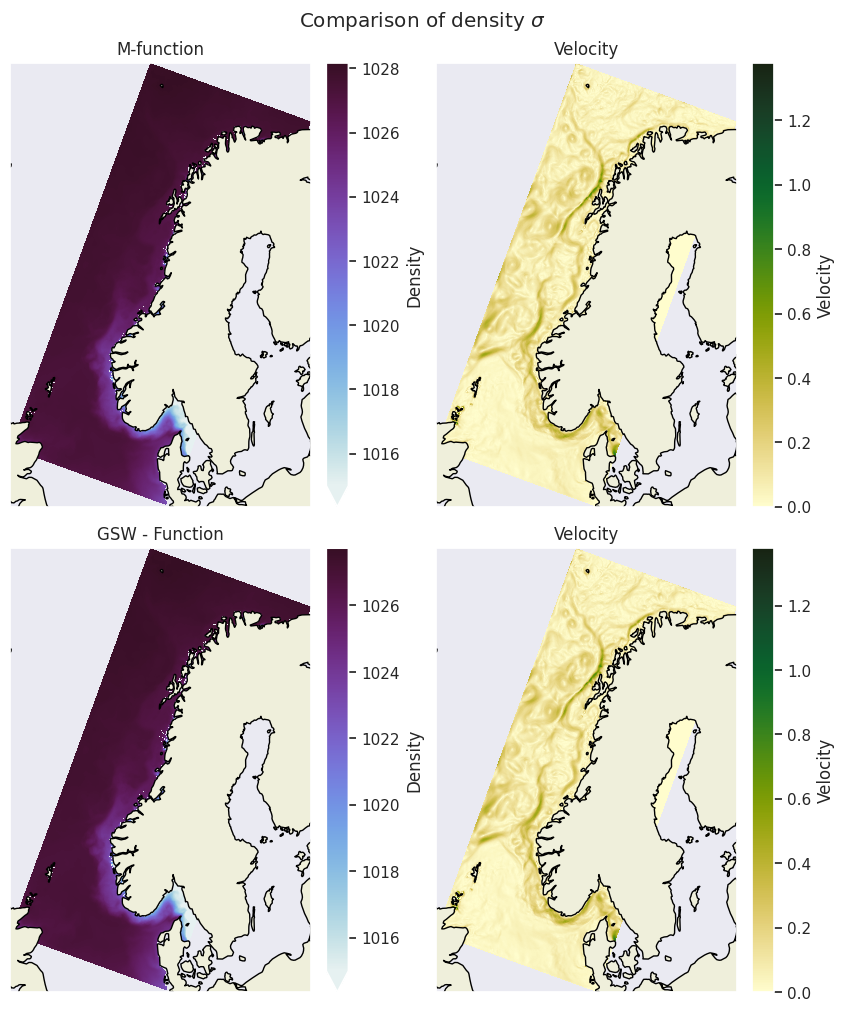

In [103]:
#Make plot of Skagerak + of northerner areas to examine whether the field looks plausible or not and compared to velocity field (focusing on fronts)

"""WHOLE OF NORWAY"""

fig, axes = plt.subplots(2,2, figsize = (12, 10), layout = 'compressed', subplot_kw= {'projection' : ccrs.NorthPolarStereo()})

#Own function
my_density = axes[0][0]
im1 = my_density.pcolormesh(ds_avg.lon, ds_avg.lat, density_field_avg, cmap = cmocean.cm.dense, transform = ccrs.PlateCarree(), vmin = 1015)
my_density.set_title(f'M-function') 
my_density.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar1 = fig.colorbar(im1, ax=my_density, orientation = 'vertical', extend = 'min')
cbar1.set_label('Density', fontsize = 12)

#GSW function
norkyst_velocity = axes[0][1]
u,v = ds_avg['u_eastward'].values, ds_avg['v_northward'].values
mean_vel = np.sqrt(u**2 + v**2)
im2 = norkyst_velocity.pcolormesh(ds_avg.lon, ds_avg.lat, mean_vel , cmap = cmocean.cm.speed, transform = ccrs.PlateCarree())
norkyst_velocity.set_title(f'Velocity') 
norkyst_velocity.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar2 = fig.colorbar(im2, ax=norkyst_velocity, orientation = 'vertical')
cbar2.set_label('Velocity', fontsize = 12)

#diff
gsw_density = axes[1][0]
im3 = gsw_density.pcolormesh(ds_avg.lon, ds_avg.lat, density_avg_gsw, cmap = cmocean.cm.dense, transform = ccrs.PlateCarree(), vmin = 1015)
gsw_density.set_title(f'GSW - Function') 
gsw_density.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar2 = fig.colorbar(im3, ax=gsw_density, orientation = 'vertical', extend = 'min')
cbar2.set_label('Density', fontsize = 12)

#diff
norkyst_velocity2 = axes[1][1]
im4 = norkyst_velocity2.pcolormesh(ds_avg.lon, ds_avg.lat, mean_vel, cmap = cmocean.cm.speed, transform = ccrs.PlateCarree())
norkyst_velocity2.set_title(f'Velocity') 
norkyst_velocity2.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar2 = fig.colorbar(im4, ax=norkyst_velocity2, orientation = 'vertical')
cbar2.set_label('Velocity', fontsize = 12)

for ax in [my_density, norkyst_velocity, gsw_density, norkyst_velocity2]:
    ax.set_ylabel('Latitude')
    ax.set_xlabel('Longitude')
    
plt.suptitle(r'Comparison of density $\sigma$')
plt.show()


In [104]:
ds_avg

<xarray.Dataset> Size: 214MB
Dimensions:           (Y: 1148, X: 2747)
Coordinates:
    s_rho             float64 8B ...
  * X                 (X) float64 22kB 0.0 800.0 1.6e+03 ... 2.196e+06 2.197e+06
  * Y                 (Y) float64 9kB 0.0 800.0 1.6e+03 ... 9.168e+05 9.176e+05
    s_w               float64 8B ...
    lon               (Y, X) float64 25MB 8.7 8.706 8.711 ... 18.29 18.31 18.33
    lat               (Y, X) float64 25MB 54.29 54.3 54.31 ... 75.71 75.72 75.73
Data variables: (12/18)
    Uwind_eastward    (Y, X) float32 13MB ...
    Vwind_northward   (Y, X) float32 13MB ...
    zeta              (Y, X) float32 13MB ...
    ubar_eastward     (Y, X) float32 13MB ...
    vbar_northward    (Y, X) float32 13MB ...
    u_eastward        (Y, X) float32 13MB 0.0 0.0 0.0 ... -0.07568 -0.07568
    ...                ...
    hc                float64 8B ...
    Cs_r              float64 8B ...
    Cs_w              float64 8B ...
    h                 (Y, X) float32 13MB ...
    projection_stere  float64 8B ...
    depth             float64 8B ...
Attributes: (12/33)
    id:                      269f9aec-22a2-423e-8f43-6dd38a36bf34
    naming_authority:        no.met
    operational_status:      scientific
    iso_topic_category:      oceans
    activity_type:           Numerical Simulation
    keywords_vocabulary:     GCMDSK:GCMD Science Keywords:https://gcmd.earthd...
    ...                      ...
    project:                 Norkyst_v3
    license:                 https://spdx.org/licenses/CC-BY-4.0 (CC-BY-4.0)
    title:                   Norkyst-800m - ROMS, Norkyst-800m ocean hindcast...
    summary:                 Norkyst-800m (Norwegian Coast 800m horizontal re...
    title_no:                Hindcast prognoser fra havmodellen Norkyst-800m,...
    summary_no:              NorKyst-800m (Norske kystområder med 800m horiso...

In [105]:
north = ds_avg.isel(X = slice(1450,None))

In [106]:
#Northern Areas 

salinity_north = north.salinity.values
temperature_north = north.temperature.values

eta_target_north, _ = entropy(SA = salinity_north, Theta= temperature_north)
density_field_north, density_field_avg_amomaly = density_field(SA = salinity_north, entropy_tar= eta_target_north)

theta = [[       nan        nan        nan ... 2.2333958  2.2367175  2.2349584 ]
 [       nan        nan        nan ... 2.2195892  2.2200456  2.2331355 ]
 [       nan        nan        nan ... 2.220273   2.2215762  2.2366846 ]
 ...
 [7.697858   7.691702   7.685678   ... 0.37498403 0.3955958  0.4497464 ]
 [7.709644   7.70261    7.696489   ... 0.4475973  0.465539   0.50448316]
 [7.7446146  7.7380705  7.732633   ... 0.5255507  0.5442088  0.52437854]], h0 = [[       nan        nan        nan ...  8915.421   8928.681   8921.659 ]
 [       nan        nan        nan ...  8860.307   8862.129   8914.382 ]
 [       nan        nan        nan ...  8863.037   8868.239   8928.55  ]
 ...
 [30728.832  30704.258  30680.21   ...  1496.8867  1579.1661  1795.3282]
 [30775.88   30747.803  30723.367  ...  1786.7493  1858.3702  2013.8302]
 [30915.479  30889.355  30867.65   ...  2097.929   2172.4097  2093.2498]], Theta = [[       nan        nan        nan ... 2.2333958  2.2367175  2.2349584 ]
 [       nan    

In [107]:
"""Northern"""
density_avg_gsw_north_ = gsw.sigma0(salinity_north, temperature_north)
density_avg_gsw_north_ += 1000

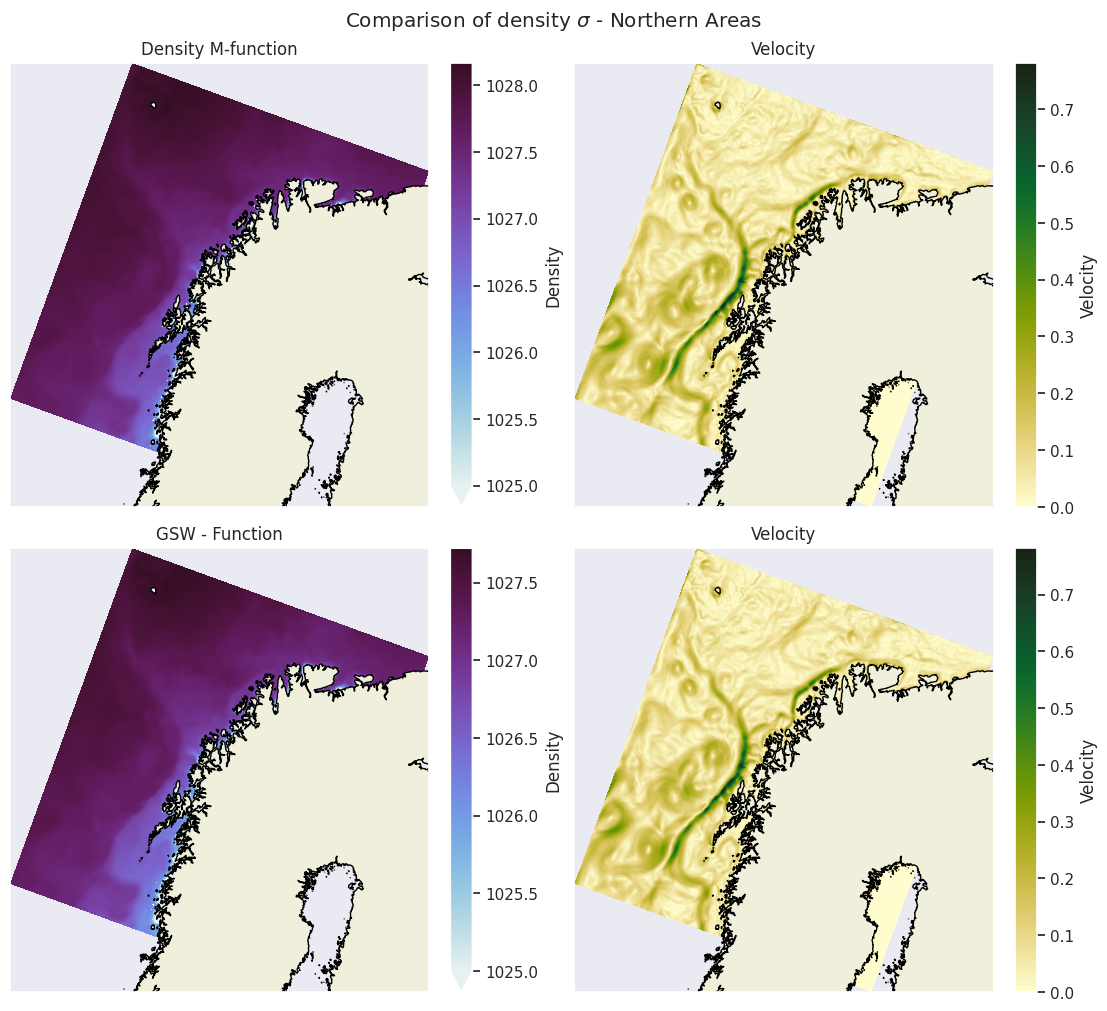

In [108]:
#Make plot of Skagerak + of northerner areas to examine whether the field looks plausible or not and compared to velocity field (focusing on fronts)

"""Northern"""

fig, axes = plt.subplots(2,2, figsize = (12, 10), layout = 'compressed', subplot_kw= {'projection' : ccrs.NorthPolarStereo()})

#Own function
my_density = axes[0][0]
im1 = my_density.pcolormesh(north.lon,north.lat, density_field_north, cmap = cmocean.cm.dense, transform = ccrs.PlateCarree(), vmin = 1025)
my_density.set_title(f'Density M-function') 
my_density.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar1 = fig.colorbar(im1, ax=my_density, orientation = 'vertical', extend = 'min')
cbar1.set_label('Density', fontsize = 12)

#GSW function
norkyst_velocity = axes[0][1]
u,v = north['u_eastward'].values, north['v_northward'].values
mean_vel = np.sqrt(u**2 + v**2)
im2 = norkyst_velocity.pcolormesh(north.lon, north.lat, mean_vel , cmap = cmocean.cm.speed, transform = ccrs.PlateCarree())
norkyst_velocity.set_title(f'Velocity') 
norkyst_velocity.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar2 = fig.colorbar(im2, ax=norkyst_velocity, orientation = 'vertical')
cbar2.set_label('Velocity', fontsize = 12)

#diff
gsw_density = axes[1][0]
im3 = gsw_density.pcolormesh(north.lon, north.lat, density_avg_gsw_north_, cmap = cmocean.cm.dense, transform = ccrs.PlateCarree(), vmin = 1025)
gsw_density.set_title(f'GSW - Function') 
gsw_density.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar2 = fig.colorbar(im3, ax=gsw_density, orientation = 'vertical', extend = 'min')
cbar2.set_label('Density', fontsize = 12)

#diff
norkyst_velocity2 = axes[1][1]
im4 = norkyst_velocity2.pcolormesh(north.lon , north.lat, mean_vel, cmap = cmocean.cm.speed, transform = ccrs.PlateCarree())
norkyst_velocity2.set_title(f'Velocity') 
norkyst_velocity2.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar2 = fig.colorbar(im4, ax=norkyst_velocity2, orientation = 'vertical')
cbar2.set_label('Velocity', fontsize = 12)

for ax in [my_density, norkyst_velocity, gsw_density, norkyst_velocity2]:
    ax.set_ylabel('Latitude')
    ax.set_xlabel('Longitude')
    
plt.suptitle(r'Comparison of density $\sigma$ - Northern Areas')
plt.show()


In [109]:
print(np.nanmax(density_avg_gsw_north_))

1027.7232788690264
